In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from PIL import Image
from tqdm import tqdm
import cv2
import os

In [2]:
BASE_DIR=r"D:\SEM-6\DL\DEEP-FAKE\DataSets\RealvsFake"

In [6]:
VALID_EXT = (".jpg", ".jpeg", ".png")
def load_data():
    data = []

    for label in ["real", "fake"]:
        folder = os.path.join(BASE_DIR, label)
        for img in os.listdir(folder):
            if img.lower().endswith(VALID_EXT):
                data.append({
                    "path": os.path.join(folder, img),
                    "label": label
                })

    return pd.DataFrame(data)

In [7]:
df = load_data()

In [9]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

In [10]:
print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)

print("\nLabel distribution:")
print("Train\n", train_df["label"].value_counts())
print("Val\n", val_df["label"].value_counts())
print("Test\n", test_df["label"].value_counts())

Train: (1428, 2)
Val  : (306, 2)
Test : (307, 2)

Label distribution:
Train
 label
real    756
fake    672
Name: count, dtype: int64
Val
 label
real    162
fake    144
Name: count, dtype: int64
Test
 label
real    163
fake    144
Name: count, dtype: int64


In [11]:
print(train_df.head())
print(train_df["label"].value_counts())

                                                   path label
1343  D:\SEM-6\DL\DEEP-FAKE\DataSets\RealvsFake\fake...  fake
1244  D:\SEM-6\DL\DEEP-FAKE\DataSets\RealvsFake\fake...  fake
1619  D:\SEM-6\DL\DEEP-FAKE\DataSets\RealvsFake\fake...  fake
1250  D:\SEM-6\DL\DEEP-FAKE\DataSets\RealvsFake\fake...  fake
488   D:\SEM-6\DL\DEEP-FAKE\DataSets\RealvsFake\real...  real
label
real    756
fake    672
Name: count, dtype: int64


In [ ]:
print(test_df.head())
print(test_df["label"].value_counts())

                                                   path label
296   D:\SEM-6\DL\DEEP-FAKE\DataSets\RealvsFake\real...  real
253   D:\SEM-6\DL\DEEP-FAKE\DataSets\RealvsFake\real...  real
996   D:\SEM-6\DL\DEEP-FAKE\DataSets\RealvsFake\real...  real
814   D:\SEM-6\DL\DEEP-FAKE\DataSets\RealvsFake\real...  real
1647  D:\SEM-6\DL\DEEP-FAKE\DataSets\RealvsFake\fake...  fake
label
real    163
fake    144
Name: count, dtype: int64


In [13]:
print(val_df.head())
print(val_df["label"].value_counts())

                                                   path label
1557  D:\SEM-6\DL\DEEP-FAKE\DataSets\RealvsFake\fake...  fake
1051  D:\SEM-6\DL\DEEP-FAKE\DataSets\RealvsFake\real...  real
601   D:\SEM-6\DL\DEEP-FAKE\DataSets\RealvsFake\real...  real
38    D:\SEM-6\DL\DEEP-FAKE\DataSets\RealvsFake\real...  real
291   D:\SEM-6\DL\DEEP-FAKE\DataSets\RealvsFake\real...  real
label
real    162
fake    144
Name: count, dtype: int64


In [14]:
def resolution_eda(df, name, plot_sample=4000):

    widths  = np.empty(len(df), dtype=np.int32)
    heights = np.empty(len(df), dtype=np.int32)

    bad = 0

    for i, path in enumerate(tqdm(df["path"], desc=f"{name} scan")):
        try:
            with Image.open(path) as img:
                w, h = img.size
        except:
            w, h = -1, -1
            bad += 1

        widths[i]  = w
        heights[i] = h

    df = df.copy()
    df["width"]  = widths
    df["height"] = heights

    df = df[df["width"] > 0]

    print(f"\n{name} corrupted images:", bad)

    print(f"\n{name} resolution statistics:")
    print(df[["width", "height"]].describe())

    if len(df) > plot_sample:
        plot_df = df.sample(plot_sample, random_state=42)
    else:
        plot_df = df

    plt.figure(figsize=(6,5))
    plt.scatter(
        plot_df["width"],
        plot_df["height"],
        s=4,
        alpha=0.3
    )
    plt.xlabel("Width")
    plt.ylabel("Height")
    plt.title(f"{name} Resolution Distribution")
    plt.show()

    return df


Train scan: 100%|██████████| 1428/1428 [00:00<00:00, 12881.04it/s]


Train corrupted images: 0

Train resolution statistics:
        width  height
count  1428.0  1428.0
mean    600.0   600.0
std       0.0     0.0
min     600.0   600.0
25%     600.0   600.0
50%     600.0   600.0
75%     600.0   600.0
max     600.0   600.0


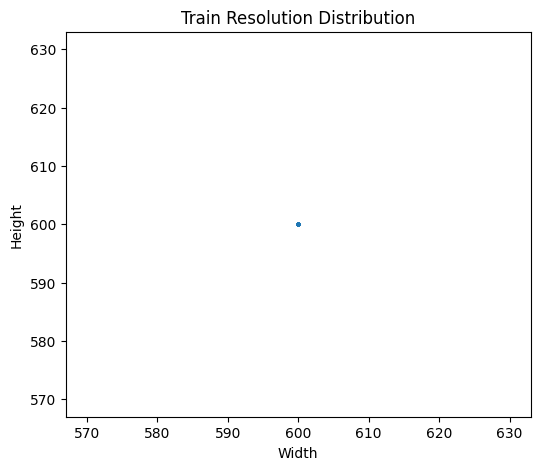

Validation scan: 100%|██████████| 306/306 [00:00<00:00, 11860.03it/s]



Validation corrupted images: 0

Validation resolution statistics:
       width  height
count  306.0   306.0
mean   600.0   600.0
std      0.0     0.0
min    600.0   600.0
25%    600.0   600.0
50%    600.0   600.0
75%    600.0   600.0
max    600.0   600.0


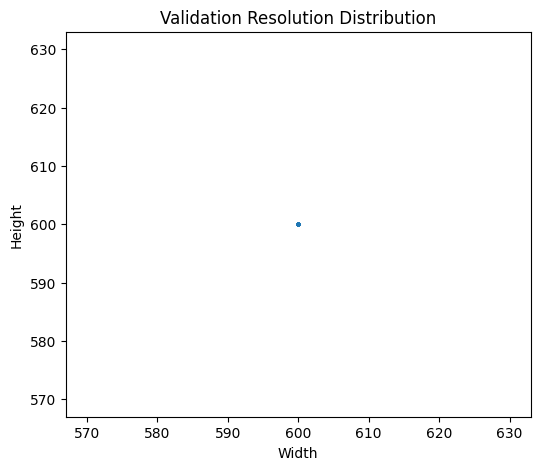

Test scan: 100%|██████████| 307/307 [00:00<00:00, 12036.15it/s]



Test corrupted images: 0

Test resolution statistics:
       width  height
count  307.0   307.0
mean   600.0   600.0
std      0.0     0.0
min    600.0   600.0
25%    600.0   600.0
50%    600.0   600.0
75%    600.0   600.0
max    600.0   600.0


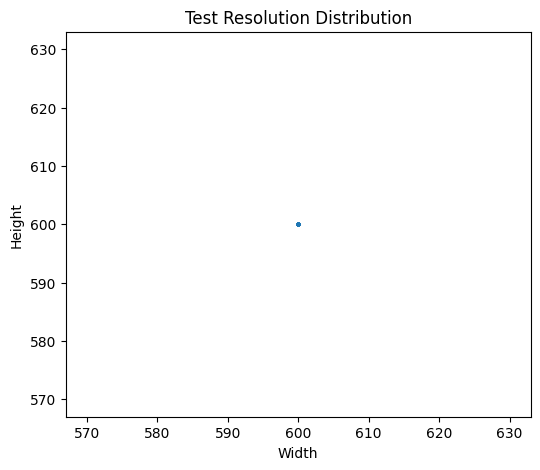

In [15]:
train_res = resolution_eda(train_df, "Train")
val_res   = resolution_eda(val_df, "Validation")
test_res  = resolution_eda(test_df, "Test")

In [16]:
def aspect_ratio_eda(res_df, name):

    res_df["aspect_ratio"] = res_df["width"] / res_df["height"]

    sns.histplot(res_df["aspect_ratio"], bins=50)
    plt.title(f"{name} Aspect Ratio Distribution")
    plt.show()

    print(res_df["aspect_ratio"].describe())

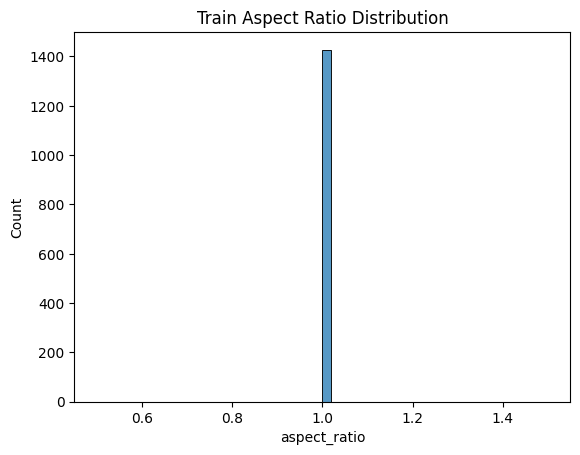

count    1428.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: aspect_ratio, dtype: float64


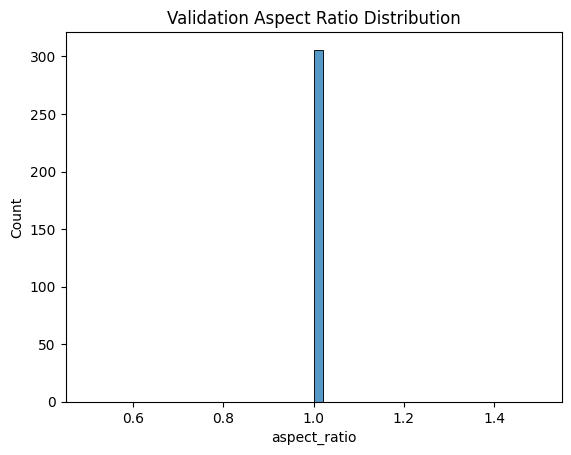

count    306.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0
Name: aspect_ratio, dtype: float64


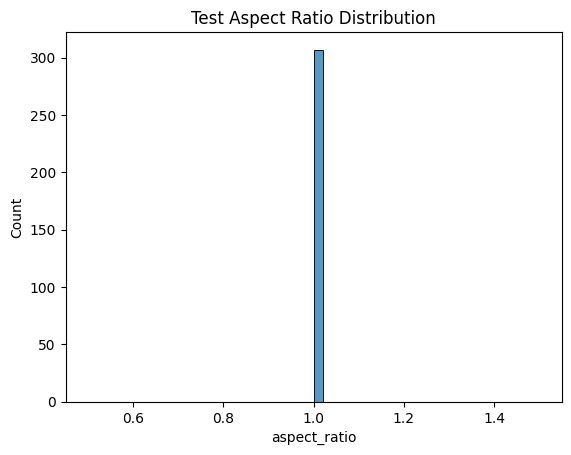

count    307.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0
Name: aspect_ratio, dtype: float64


In [17]:
aspect_ratio_eda(train_res, "Train")
aspect_ratio_eda(val_res, "Validation")
aspect_ratio_eda(test_res, "Test")

In [18]:
def brightness_contrast_eda(df, name, sample=4000):

    sample_size = min(sample, len(df))
    temp = df.sample(sample_size, random_state=42)

    brightness = []
    contrast   = []

    for path in tqdm(temp["path"], desc=f"{name} brightness"):
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue  # skip broken images

        brightness.append(img.mean())
        contrast.append(img.std())

    temp = temp.iloc[:len(brightness)].copy()
    temp["brightness"] = brightness
    temp["contrast"]   = contrast

    sns.kdeplot(data=temp, x="brightness", hue="label", fill=True)
    plt.title(f"{name} Brightness Distribution")
    plt.show()

    sns.kdeplot(data=temp, x="contrast", hue="label", fill=True)
    plt.title(f"{name} Contrast Distribution")
    plt.show()

Train brightness: 100%|██████████| 1428/1428 [00:08<00:00, 163.40it/s]


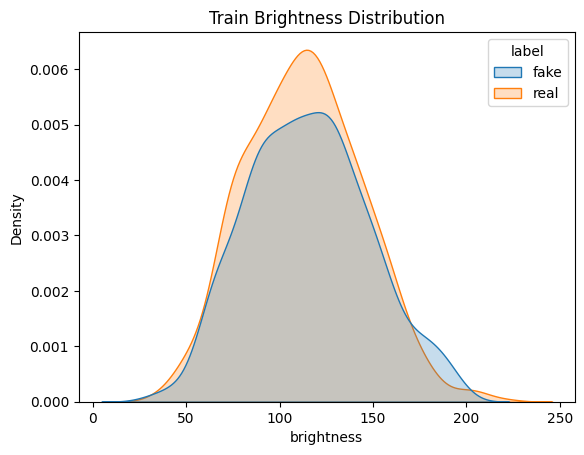

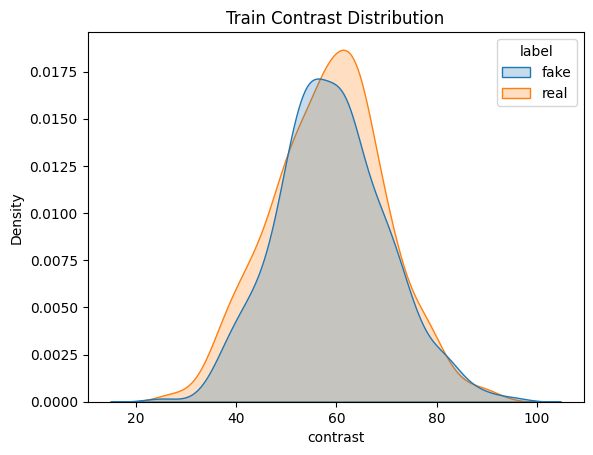

Validation brightness: 100%|██████████| 306/306 [00:02<00:00, 139.80it/s]


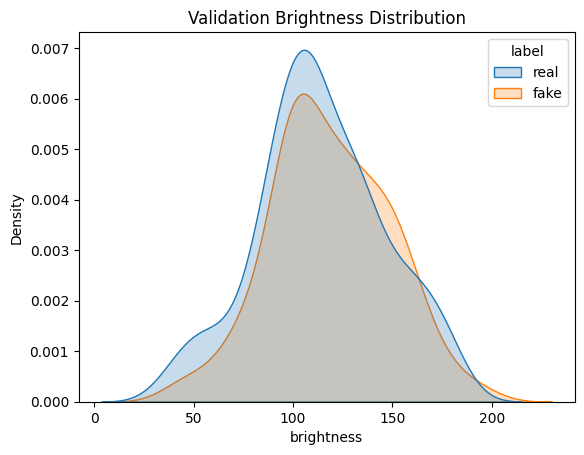

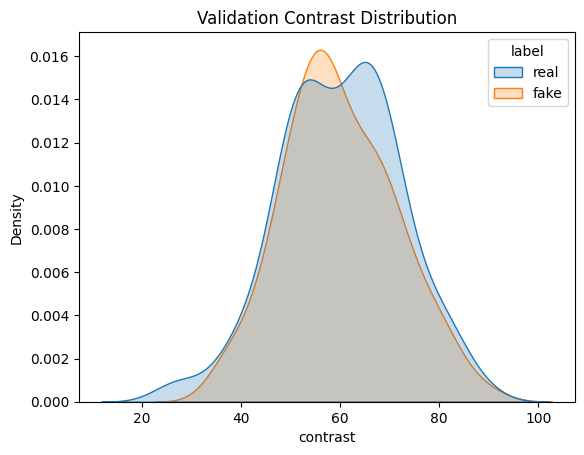

Test brightness: 100%|██████████| 307/307 [00:01<00:00, 158.19it/s]


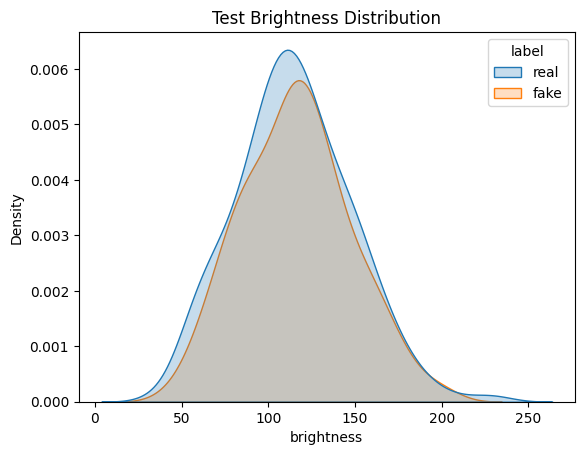

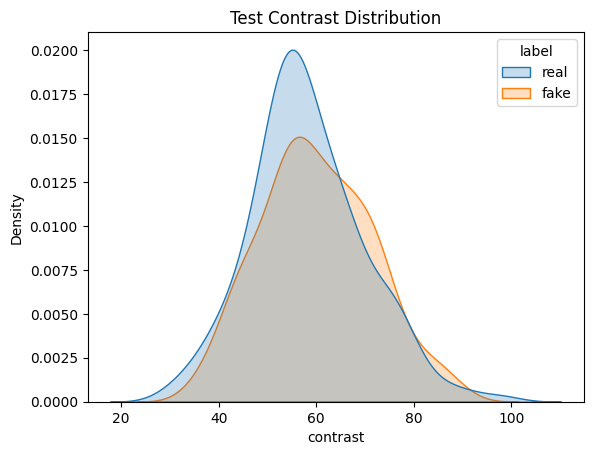

In [19]:
brightness_contrast_eda(train_df, "Train")
brightness_contrast_eda(val_df, "Validation")
brightness_contrast_eda(test_df, "Test")

In [20]:
def rgb_channel_eda(df, name):

    R, G, B = [], [], []

    for path in tqdm(df["path"], desc=f"{name} RGB"):
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        r, g, b = img.mean(axis=(0,1))
        R.append(r); G.append(g); B.append(b)

    plt.figure(figsize=(8,5))
    sns.kdeplot(R, label="R")
    sns.kdeplot(G, label="G")
    sns.kdeplot(B, label="B")
    plt.title(f"{name} RGB Channel Means")
    plt.legend()
    plt.show()

Train RGB: 100%|██████████| 1428/1428 [00:13<00:00, 103.87it/s]


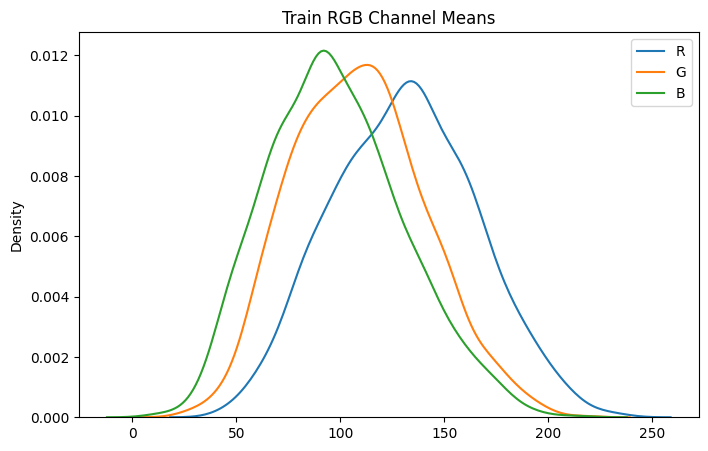

Validate RGB: 100%|██████████| 306/306 [00:02<00:00, 105.63it/s]


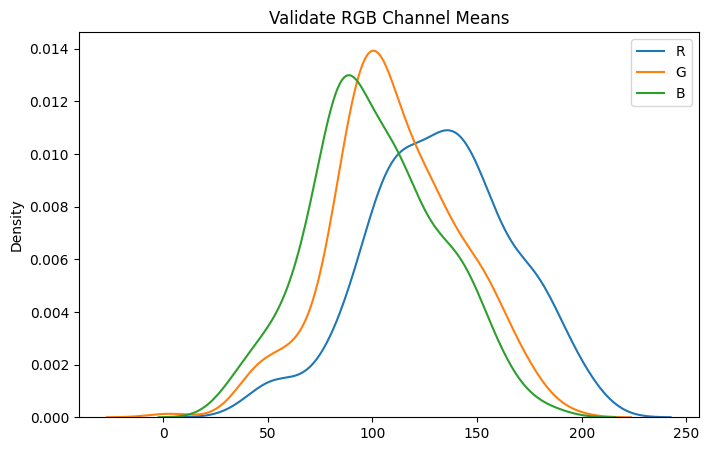

Test RGB: 100%|██████████| 307/307 [00:02<00:00, 107.40it/s]


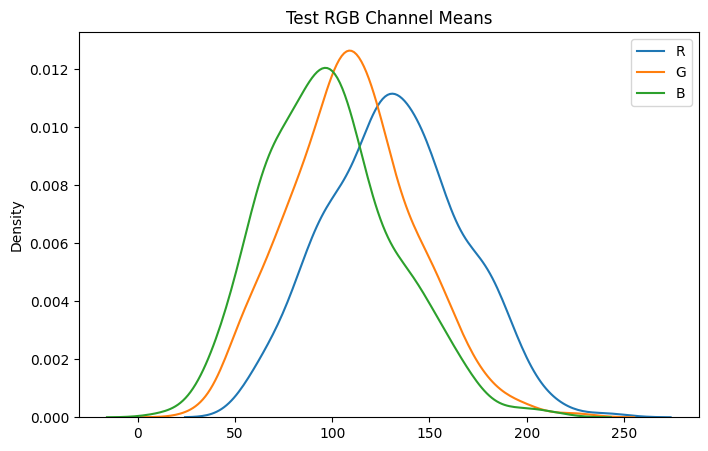

In [21]:
rgb_channel_eda(train_df,"Train")
rgb_channel_eda(val_df,"Validate")
rgb_channel_eda(test_df,"Test")

In [22]:
def fft_energy_eda(df, name, sample=2000):

    n = min(sample, len(df))
    temp = df.sample(n=n, random_state=42)

    def fft_energy(path):
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (256,256))
        f = np.fft.fftshift(np.fft.fft2(img))
        return np.log(np.abs(f) + 1).mean()

    temp = temp.copy()  # avoid SettingWithCopy warnings
    temp["fft_energy"] = [
        fft_energy(p) for p in tqdm(temp["path"], desc=f"{name} FFT")
    ]

    sns.kdeplot(
        data=temp,
        x="fft_energy",
        hue="label",
        fill=True
    )
    plt.title(f"{name} FFT Energy Distribution")
    plt.show()

Train FFT: 100%|██████████| 1428/1428 [00:10<00:00, 137.90it/s]


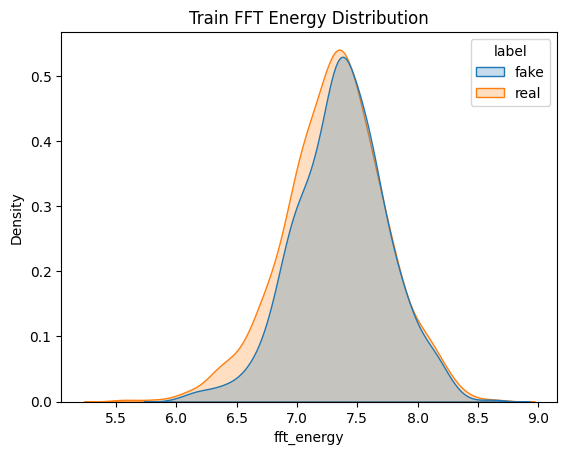

Validate FFT: 100%|██████████| 306/306 [00:02<00:00, 135.02it/s]


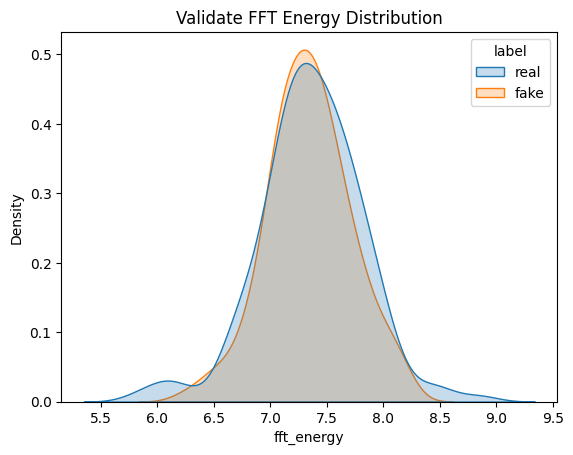

Test FFT: 100%|██████████| 307/307 [00:02<00:00, 138.92it/s]


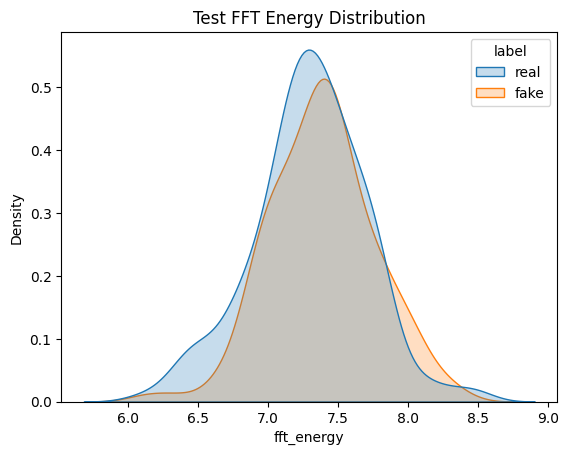

In [23]:
fft_energy_eda(train_df,"Train")
fft_energy_eda(val_df,"Validate")
fft_energy_eda(test_df,"Test")

In [26]:
def haar_face_presence_eda(df, name, sample=3000):

    face_cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
    )
    assert not face_cascade.empty(), "Haar cascade failed to load"

    sample_size = min(sample, len(df))
    temp = df.sample(sample_size, random_state=42)

    faces = []

    for path in tqdm(temp["path"], desc=f"{name} Haar face check"):
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            faces.append(0)
            continue

        detections = face_cascade.detectMultiScale(
            img,
            scaleFactor=1.1,
            minNeighbors=5,
            minSize=(40, 40)
        )

        faces.append(1 if len(detections) > 0 else 0)

    temp = temp.copy()
    temp["face"] = faces

    print(f"\n{name} face presence rate:")
    print(temp.groupby("label")["face"].mean())

In [28]:
haar_face_presence_eda(train_df, "Train")
haar_face_presence_eda(val_df, "Validation")
haar_face_presence_eda(test_df, "Test")

Train Haar face check: 100%|██████████| 1428/1428 [00:20<00:00, 68.80it/s]



Train face presence rate:
label
fake    0.903274
real    0.833333
Name: face, dtype: float64


Validation Haar face check: 100%|██████████| 306/306 [00:04<00:00, 70.11it/s]



Validation face presence rate:
label
fake    0.951389
real    0.833333
Name: face, dtype: float64


Test Haar face check: 100%|██████████| 307/307 [00:04<00:00, 69.62it/s]


Test face presence rate:
label
fake    0.888889
real    0.815951
Name: face, dtype: float64


In [38]:
import os
import cv2
import numpy as np
import random
from tqdm import tqdm
from sklearn.model_selection import train_test_split

In [39]:
INPUT_DIR  = r"D:\SEM-6\DL\DEEP-FAKE\DataSets\RealvsFake"
OUTPUT_DIR = r"D:\SEM-6\DL\DEEP-FAKE\DataSets\RealvsFake_aligned"

IMG_SIZE = 256
VALID_EXT = (".jpg", ".jpeg", ".png")

In [40]:
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

def face_center_crop(img, pad_ratio=0.3):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.1, 5)

    if len(faces) == 0:
        h, w = img.shape[:2]
        m = min(h, w)
        return img[(h-m)//2:(h+m)//2, (w-m)//2:(w+m)//2]

    x, y, w, h = max(faces, key=lambda b: b[2]*b[3])
    pad = int(max(w, h) * pad_ratio)

    x1 = max(0, x-pad)
    y1 = max(0, y-pad)
    x2 = min(img.shape[1], x+w+pad)
    y2 = min(img.shape[0], y+h+pad)

    return img[y1:y2, x1:x2]

In [41]:
def resize_256(img):
    return cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)

In [42]:
def frequency_augment(img):

    # JPEG compression
    if random.random() < 0.5:
        quality = random.randint(60, 95)
        encode = [int(cv2.IMWRITE_JPEG_QUALITY), quality]
        _, enc = cv2.imencode(".jpg", img, encode)
        img = cv2.imdecode(enc, cv2.IMREAD_COLOR)

    # Blur or sharpen
    if random.random() < 0.3:
        if random.random() < 0.5:
            img = cv2.GaussianBlur(img, (3,3), 0)
        else:
            kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
            img = cv2.filter2D(img, -1, kernel)

    return img

In [43]:
def color_jitter(img):
    img = img.astype(np.float32)

    c = random.uniform(0.9, 1.1)
    img = (img - 128) * c + 128

    b = random.uniform(-15, 15)
    img += b

    return np.clip(img, 0, 255).astype(np.uint8)

In [44]:
def preprocess_image(path, train=True):

    img = cv2.imread(path)
    if img is None:
        return None

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = face_center_crop(img)
    img = resize_256(img)

    if train:
        img = frequency_augment(img)
        img = color_jitter(img)

    return img

In [45]:
def collect_paths(base_dir):
    paths, labels = [], []

    for label in ["real", "fake"]:
        folder = os.path.join(base_dir, label)
        for f in os.listdir(folder):
            if f.lower().endswith(VALID_EXT):
                paths.append(os.path.join(folder, f))
                labels.append(label)

    return paths, labels

In [46]:
paths, labels = collect_paths(INPUT_DIR)

train_p, temp_p, train_l, temp_l = train_test_split(
    paths, labels, test_size=0.30, stratify=labels, random_state=42
)

val_p, test_p, val_l, test_l = train_test_split(
    temp_p, temp_l, test_size=0.50, stratify=temp_l, random_state=42
)

In [47]:
def save_split(paths, labels, split_name, train=True):

    for p, lbl in tqdm(zip(paths, labels), total=len(paths), desc=f"Saving {split_name}"):

        img = preprocess_image(p, train=train)
        if img is None:
            continue

        out_dir = os.path.join(OUTPUT_DIR, split_name, lbl)
        os.makedirs(out_dir, exist_ok=True)

        out_path = os.path.join(out_dir, os.path.basename(p))
        cv2.imwrite(out_path, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))

In [48]:
save_split(train_p, train_l, "train", train=True)
save_split(val_p,   val_l,   "val",   train=False)
save_split(test_p,  test_l,  "test",  train=False)

Saving test: 100%|██████████| 307/307 [00:15<00:00, 20.18it/s]
